In [41]:
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import joblib


In [42]:
home = "/project/Wellcome_Discovery/lturiano/GENESIS/"
data = "/project/Wellcome_Discovery/datashare/lturiano/data/"
sriva = "/project/Wellcome_Discovery/datashare/sriva/GENESIS/"

In [43]:
np.random.seed(42)

In [44]:
rna  = sc.read_h5ad(data+"rna_filt_aligned.h5ad")
gex  = sc.read_h5ad(data+"gex_filt_aligned.h5ad")

In [45]:
fake = sc.read_h5ad(data+"fake_PermInv_VAE_UNET.h5ad")

In [46]:
# Load genes and label encoder from meta.joblib
meta = joblib.load(home + "meta.joblib")
genes = meta["genes"]

label_encoder = LabelEncoder()
label_encoder.classes_ = meta["label_classes"]   # must match training

In [47]:
len(genes)

86

In [48]:
label_encoder.classes_

array(['T cell', 'dendritic cell', 'duct cell', 'endothelial cell',
       'epithelial cell', 'fibroblast', 'lymphocyte', 'macrophage',
       'mural cell', 'myeloid cell', 'myocyte', 'neural cell'],
      dtype='<U16')

In [49]:
df_rna = pd.DataFrame(index   = rna.obs.index,
                      columns = genes,
                      data    = rna.X[:, rna.var_names.isin(genes)])

df_gex = pd.DataFrame(index   = gex.obs.index,
                      columns = genes,
                      data    = gex.X[:, gex.var_names.isin(genes)])

df_fake = pd.DataFrame(index   = fake.obs.index,
                       columns = genes,
                       data    = fake.X[:, fake.var_names.isin(genes)])

In [50]:
df_rna["cell_type"]  = label_encoder.transform(rna.obs["cell_type"].values.tolist())
df_gex["cell_type"]  = label_encoder.transform(gex.obs["cell_type"].values.tolist())
df_fake["cell_type"] = label_encoder.transform(rna.obs["cell_type"].values.tolist())

In [51]:
# Create train-test split (final evaluation set)
X_train_rna, X_test_rna, y_train_rna, y_test_rna = train_test_split(df_rna[df_rna.columns[:-1]],
                                                                    df_rna[df_rna.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_rna[df_rna.columns[-1]]
                                                                    )

In [52]:
# Create train-test split (final evaluation set)
X_train_gex, X_test_gex, y_train_gex, y_test_gex = train_test_split(df_gex[df_gex.columns[:-1]],
                                                                    df_gex[df_gex.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_gex[df_gex.columns[-1]]
                                                                    )

In [53]:
# Create train-test split (final evaluation set)
X_train_fake, X_test_fake, y_train_fake, y_test_fake = train_test_split(df_fake[df_fake.columns[:-1]],
                                                                        df_fake[df_fake.columns[-1]],
                                                                        test_size=0.15,
                                                                        random_state=42,
                                                                        stratify=df_fake[df_fake.columns[-1]]
                                                                        )

# Performance evaluation on scRNA, scGEX, generated scGEX

In [54]:
# Load the trained XGBoost model
model_rna = xgb.XGBClassifier()
model_rna.load_model(home + "02_weights/best_xgb_model.json")

In [55]:
# y_pred_rna = model_rna.predict(X_train_rna)
# print(f'Accuracy: {accuracy_score(y_train_rna.values, y_pred_rna):.4f}')

In [56]:
y_pred_rna = model_rna.predict(X_test_rna)

# Classification report
print("Classification Report:")
print(classification_report(y_test_rna.values, y_pred_rna, target_names=label_encoder.classes_))

Classification Report:
                  precision    recall  f1-score   support

          T cell       0.99      0.98      0.99      1043
  dendritic cell       0.87      0.88      0.87       305
       duct cell       0.86      0.61      0.71       260
endothelial cell       0.99      1.00      0.99      2014
 epithelial cell       0.93      0.97      0.95      1738
      fibroblast       0.99      0.98      0.99       734
      lymphocyte       0.98      0.98      0.98      1113
      macrophage       0.87      0.80      0.84       310
      mural cell       0.99      1.00      0.99      1500
    myeloid cell       0.98      0.99      0.99      1500
         myocyte       0.99      0.94      0.96       289
     neural cell       0.92      0.94      0.93       402

        accuracy                           0.97     11208
       macro avg       0.95      0.92      0.93     11208
    weighted avg       0.97      0.97      0.97     11208



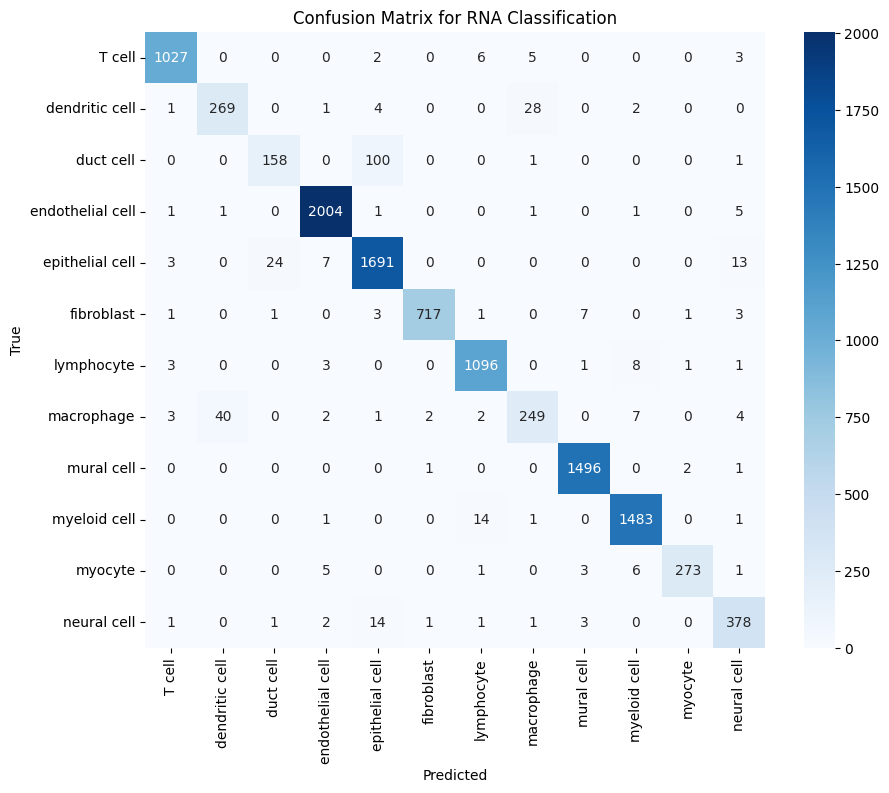

In [57]:
# Confusion matrix
cm = confusion_matrix(y_test_rna.values, y_pred_rna)

# Display confusion matrix as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for RNA Classification')
plt.show()

In [58]:
y_pred_gex = model_rna.predict(X_test_gex)

# Classification report
print("Classification Report for GEX:")
print(classification_report(y_test_gex.values, y_pred_gex, target_names=label_encoder.classes_))

Classification Report for GEX:
                  precision    recall  f1-score   support

          T cell       0.51      0.34      0.41      1043
  dendritic cell       0.38      0.16      0.23       305
       duct cell       0.71      0.12      0.21       260
endothelial cell       0.82      0.92      0.86      2014
 epithelial cell       0.61      0.67      0.64      1738
      fibroblast       0.68      0.76      0.72       734
      lymphocyte       0.66      0.50      0.56      1113
      macrophage       0.13      0.40      0.19       310
      mural cell       0.94      0.74      0.83      1500
    myeloid cell       0.85      0.04      0.08      1500
         myocyte       0.65      0.78      0.71       289
     neural cell       0.10      0.48      0.16       402

        accuracy                           0.56     11208
       macro avg       0.59      0.49      0.47     11208
    weighted avg       0.69      0.56      0.56     11208



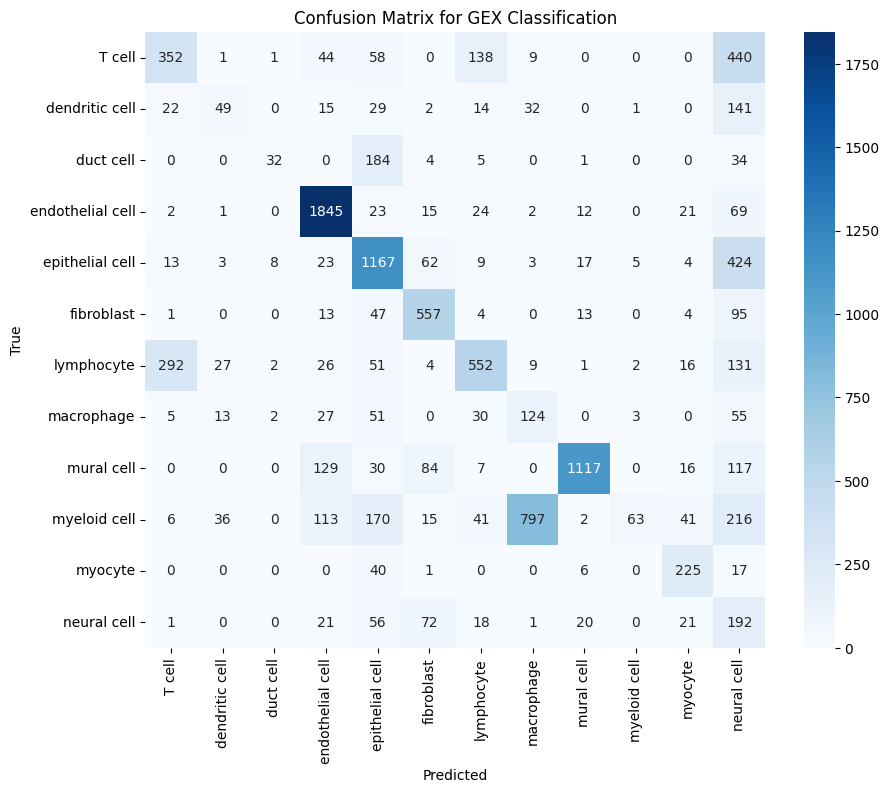

In [59]:
# Confusion matrix
cm = confusion_matrix(y_test_gex.values, y_pred_gex)
# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for GEX Classification')
plt.show()

In [60]:
y_pred_fake = model_rna.predict(X_test_fake)

# Classification report
print("Classification Report for FAKE:")
print(classification_report(y_test_fake.values, y_pred_fake, target_names=label_encoder.classes_))

Classification Report for FAKE:
                  precision    recall  f1-score   support

          T cell       0.64      1.00      0.78      1043
  dendritic cell       1.00      0.84      0.91       305
       duct cell       1.00      0.11      0.19       260
endothelial cell       0.97      0.98      0.97      2014
 epithelial cell       0.69      1.00      0.82      1738
      fibroblast       0.57      1.00      0.72       734
      lymphocyte       0.99      0.40      0.57      1113
      macrophage       0.17      1.00      0.29       310
      mural cell       1.00      0.66      0.79      1500
    myeloid cell       1.00      0.04      0.07      1500
         myocyte       0.98      0.19      0.32       289
     neural cell       1.00      0.22      0.37       402

        accuracy                           0.69     11208
       macro avg       0.83      0.62      0.57     11208
    weighted avg       0.86      0.69      0.65     11208



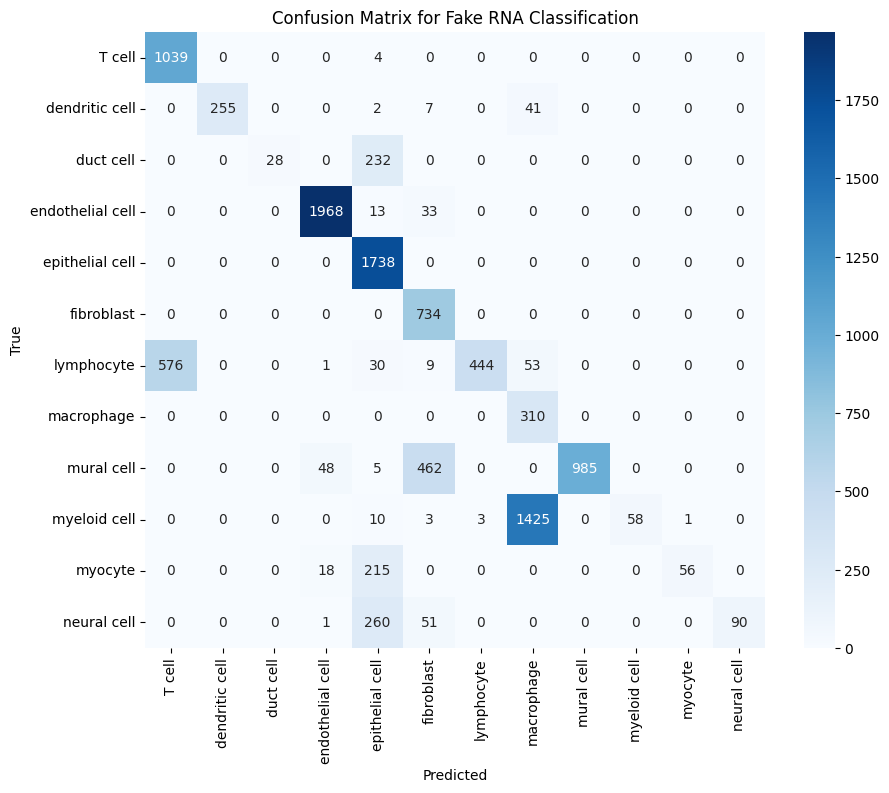

In [61]:
# Confusion matrix
cm = confusion_matrix(y_test_fake.values, y_pred_fake)

# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Fake RNA Classification')
plt.show()


# Fine-tuning on scGEX

In [62]:
# Load the trained XGBoost model
model_gex = xgb.XGBClassifier()
model_gex.load_model(home + "02_weights/best_xgb_model.json")

In [ ]:
model_gex.fit(X_train_gex, 
              y_train_gex,
              xgb_model=model_gex.get_booster(),  # Continue training from existing model
              verbose=True
              )

[11:02:44] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.



In [ ]:
y_pred_rna = model_gex.predict(X_test_rna)

# Classification report
print("Classification Report:")
print(classification_report(y_test_rna.values, y_pred_rna, target_names=label_encoder.classes_))

Classification Report:
                  precision    recall  f1-score   support

          T cell       0.99      0.98      0.99      1043
  dendritic cell       0.87      0.88      0.87       305
       duct cell       0.86      0.61      0.71       260
endothelial cell       0.99      1.00      0.99      2014
 epithelial cell       0.93      0.97      0.95      1738
      fibroblast       0.99      0.98      0.99       734
      lymphocyte       0.98      0.98      0.98      1113
      macrophage       0.87      0.80      0.84       310
      mural cell       0.99      1.00      0.99      1500
    myeloid cell       0.98      0.99      0.99      1500
         myocyte       0.99      0.94      0.96       289
     neural cell       0.92      0.94      0.93       402

        accuracy                           0.97     11208
       macro avg       0.95      0.92      0.93     11208
    weighted avg       0.97      0.97      0.97     11208



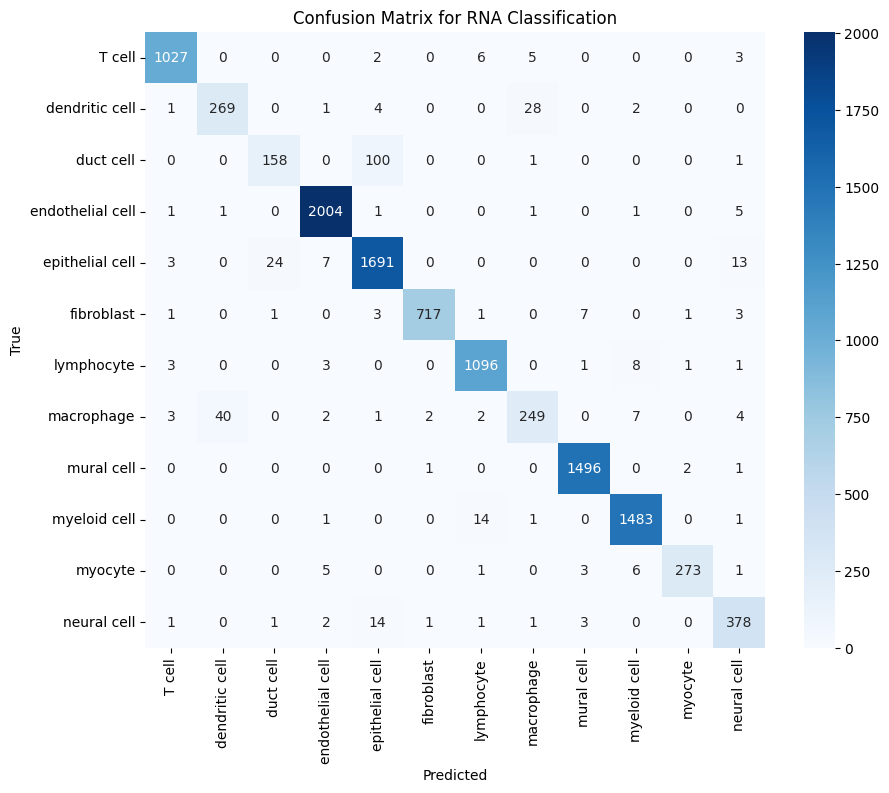

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_rna.values, y_pred_rna)

# Display confusion matrix as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for RNA Classification')
plt.show()

In [ ]:
y_pred_gex = model_gex.predict(X_test_gex)

# Classification report
print("Classification Report for GEX:")
print(classification_report(y_test_gex.values, y_pred_gex, target_names=label_encoder.classes_))

Classification Report for GEX:
                  precision    recall  f1-score   support

          T cell       0.51      0.34      0.41      1043
  dendritic cell       0.38      0.16      0.23       305
       duct cell       0.71      0.12      0.21       260
endothelial cell       0.82      0.92      0.86      2014
 epithelial cell       0.61      0.67      0.64      1738
      fibroblast       0.68      0.76      0.72       734
      lymphocyte       0.66      0.50      0.56      1113
      macrophage       0.13      0.40      0.19       310
      mural cell       0.94      0.74      0.83      1500
    myeloid cell       0.85      0.04      0.08      1500
         myocyte       0.65      0.78      0.71       289
     neural cell       0.10      0.48      0.16       402

        accuracy                           0.56     11208
       macro avg       0.59      0.49      0.47     11208
    weighted avg       0.69      0.56      0.56     11208



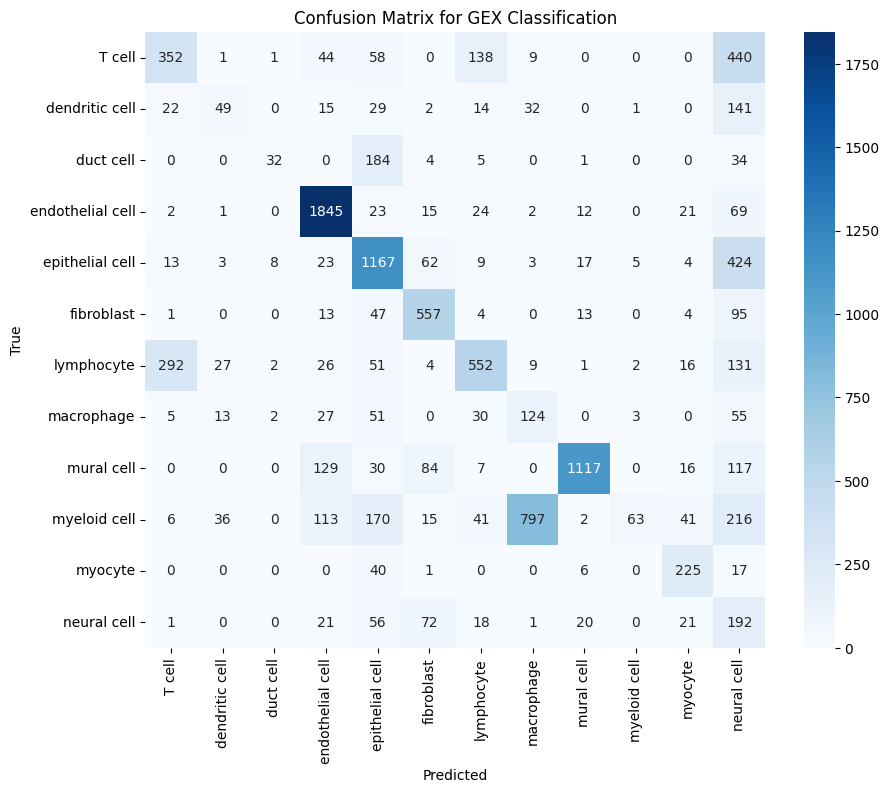

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_gex.values, y_pred_gex)
# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for GEX Classification')
plt.show()

In [ ]:
y_pred_fake = model_gex.predict(X_test_fake)

# Classification report
print("Classification Report for FAKE:")
print(classification_report(y_test_fake.values, y_pred_fake, target_names=label_encoder.classes_))

Classification Report for FAKE:
                  precision    recall  f1-score   support

          T cell       0.64      1.00      0.78      1043
  dendritic cell       1.00      0.84      0.91       305
       duct cell       1.00      0.11      0.19       260
endothelial cell       0.97      0.98      0.97      2014
 epithelial cell       0.69      1.00      0.82      1738
      fibroblast       0.57      1.00      0.72       734
      lymphocyte       0.99      0.40      0.57      1113
      macrophage       0.17      1.00      0.29       310
      mural cell       1.00      0.66      0.79      1500
    myeloid cell       1.00      0.04      0.07      1500
         myocyte       0.98      0.19      0.32       289
     neural cell       1.00      0.22      0.37       402

        accuracy                           0.69     11208
       macro avg       0.83      0.62      0.57     11208
    weighted avg       0.86      0.69      0.65     11208



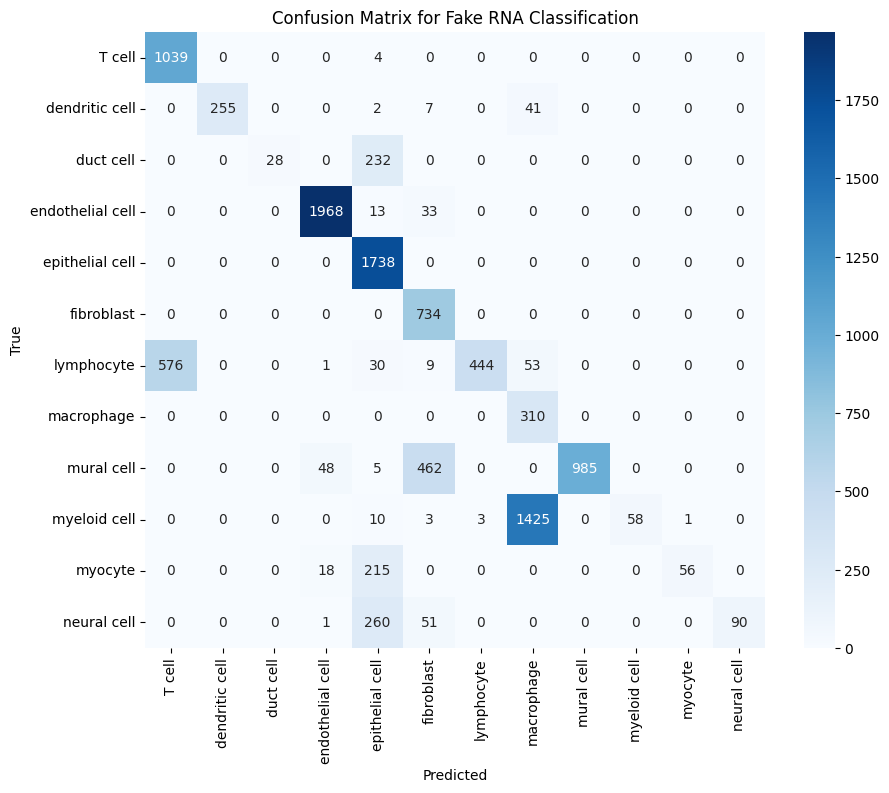

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_fake.values, y_pred_fake)

# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Fake RNA Classification')
plt.show()


# Fine-tuning on generated scRNA

In [ ]:
# Load the trained XGBoost model
model_fake = xgb.XGBClassifier()
model_fake.load_model(home + "02_weights/best_xgb_model.json")

In [ ]:
model_fake.fit(X_train_fake, 
               y_train_fake,
               xgb_model=model_fake.get_booster(),  # Continue training from existing model
               verbose=True
               )

In [ ]:
y_pred_rna = model_fake.predict(X_test_rna)

# Classification report
print("Classification Report:")
print(classification_report(y_test_rna.values, y_pred_rna, target_names=label_encoder.classes_))

Classification Report:
                  precision    recall  f1-score   support

          T cell       0.99      0.98      0.99      1043
  dendritic cell       0.87      0.88      0.87       305
       duct cell       0.86      0.61      0.71       260
endothelial cell       0.99      1.00      0.99      2014
 epithelial cell       0.93      0.97      0.95      1738
      fibroblast       0.99      0.98      0.99       734
      lymphocyte       0.98      0.98      0.98      1113
      macrophage       0.87      0.80      0.84       310
      mural cell       0.99      1.00      0.99      1500
    myeloid cell       0.98      0.99      0.99      1500
         myocyte       0.99      0.94      0.96       289
     neural cell       0.92      0.94      0.93       402

        accuracy                           0.97     11208
       macro avg       0.95      0.92      0.93     11208
    weighted avg       0.97      0.97      0.97     11208



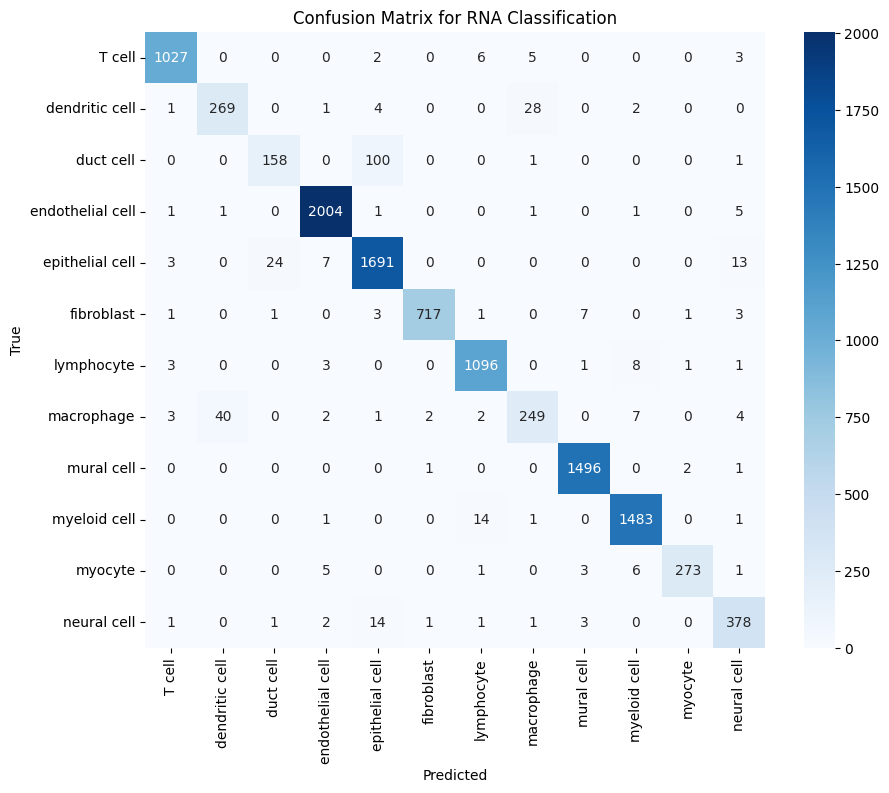

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_rna.values, y_pred_rna)

# Display confusion matrix as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for RNA Classification')
plt.show()

In [ ]:
y_pred_gex = model_fake.predict(X_test_gex)

# Classification report
print("Classification Report for GEX:")
print(classification_report(y_test_gex.values, y_pred_gex, target_names=label_encoder.classes_))

Classification Report for GEX:
                  precision    recall  f1-score   support

          T cell       0.51      0.34      0.41      1043
  dendritic cell       0.38      0.16      0.23       305
       duct cell       0.71      0.12      0.21       260
endothelial cell       0.82      0.92      0.86      2014
 epithelial cell       0.61      0.67      0.64      1738
      fibroblast       0.68      0.76      0.72       734
      lymphocyte       0.66      0.50      0.56      1113
      macrophage       0.13      0.40      0.19       310
      mural cell       0.94      0.74      0.83      1500
    myeloid cell       0.85      0.04      0.08      1500
         myocyte       0.65      0.78      0.71       289
     neural cell       0.10      0.48      0.16       402

        accuracy                           0.56     11208
       macro avg       0.59      0.49      0.47     11208
    weighted avg       0.69      0.56      0.56     11208



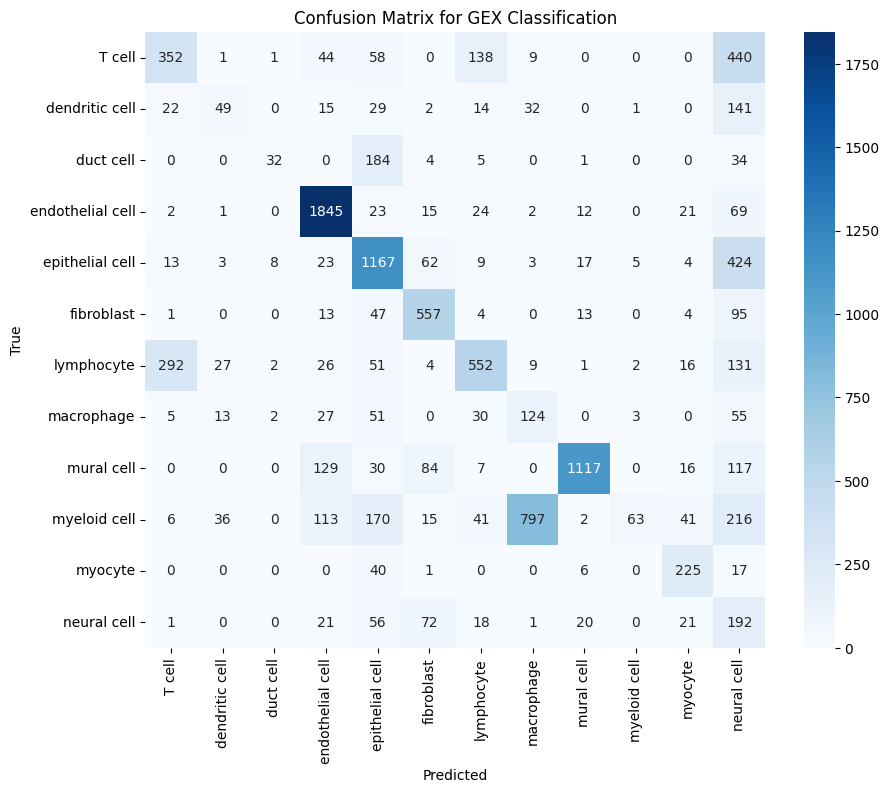

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_gex.values, y_pred_gex)
# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for GEX Classification')
plt.show()

In [ ]:
y_pred_fake = model_fake.predict(X_test_fake)

# Classification report
print("Classification Report for FAKE:")
print(classification_report(y_test_fake.values, y_pred_fake, target_names=label_encoder.classes_))

Classification Report for FAKE:
                  precision    recall  f1-score   support

          T cell       0.64      1.00      0.78      1043
  dendritic cell       1.00      0.84      0.91       305
       duct cell       1.00      0.11      0.19       260
endothelial cell       0.97      0.98      0.97      2014
 epithelial cell       0.69      1.00      0.82      1738
      fibroblast       0.57      1.00      0.72       734
      lymphocyte       0.99      0.40      0.57      1113
      macrophage       0.17      1.00      0.29       310
      mural cell       1.00      0.66      0.79      1500
    myeloid cell       1.00      0.04      0.07      1500
         myocyte       0.98      0.19      0.32       289
     neural cell       1.00      0.22      0.37       402

        accuracy                           0.69     11208
       macro avg       0.83      0.62      0.57     11208
    weighted avg       0.86      0.69      0.65     11208



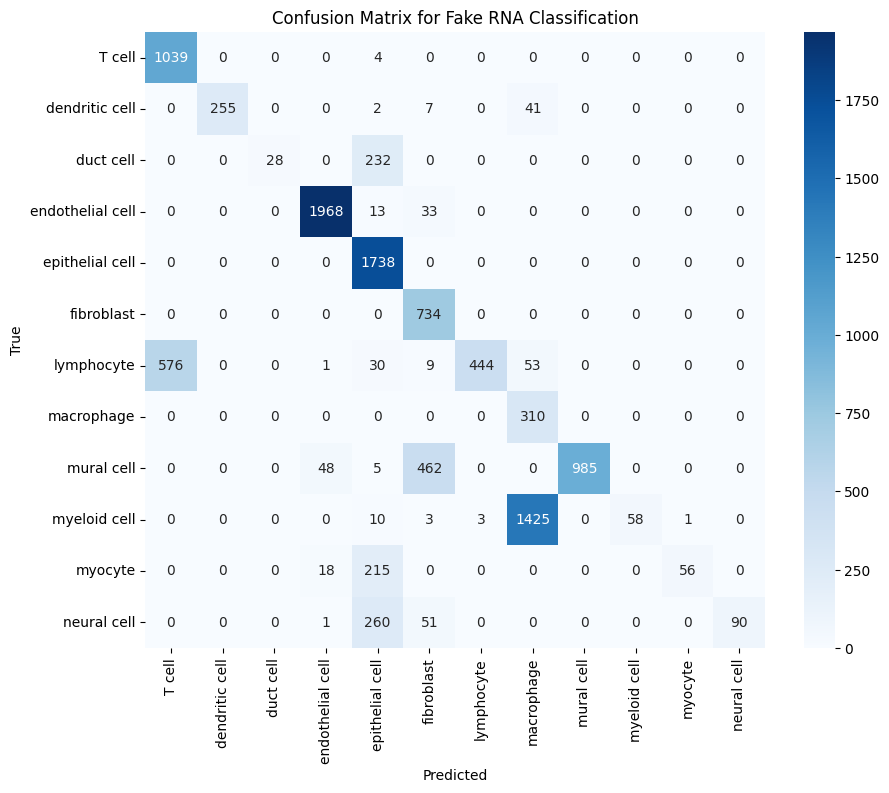

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_fake.values, y_pred_fake)

# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Fake RNA Classification')
plt.show()


# Test on BREAST data

In [29]:
# Load breast data
rna = sc.read_h5ad(sriva+"RNA_filt_log_subset.h5ad")
gex = sc.read_h5ad(sriva+"GEX_filt_log_subset.h5ad")
fake = sc.read_h5ad(data+"breast_fake_rand_RNA_PermInv_VAE_UNET.h5ad")

In [67]:
rna.obs["cell_type"].value_counts()

cell_type
endothelial cell    13425
epithelial cell     11588
mural cell          10000
myeloid cell        10000
lymphocyte           7421
T cell               6955
fibroblast           4892
neural cell          2680
macrophage           2067
dendritic cell       2031
myocyte              1924
duct cell            1734
Name: count, dtype: int64

In [30]:
marker_genes = {'T cell': ['IL7R', 'CCL5', 'PTPRC', 'CXCR4', 'GNLY', 'CD2', 'SRGN'],
                'basal cell': ['KRT14', 'KRT17', 'DST', 'KRT5', 'SAA1', 'ACTA2', 'SFN'],
                'endothelial cell': ['SELE', 'ACKR1', 'FABP4', 'STC1', 'ANGPT2', 'CSF3'],
                'fibroblast': ['DCN', 'APOD', 'CFD', 'TNFAIP6', 'LUM', 'COL1A2', 'COL1A1'],
                'macrophage': ['HLA-DRA', 'IL1B', 'HLA-DPA1', 'HLA-DPB1', 'HLA-DRB1', 'CD74', 'CCL3']
              }

In [31]:
genes = []

for row in list(marker_genes.values()):
    for item in row:
        if item not in genes:
            genes.append(item)
            
# np.random.shuffle(genes)

In [32]:
df_rna = pd.DataFrame(index   = rna.obs.index,
                      columns = genes,
                      data    = rna.X[:, rna.var.feature_name.isin(genes)])

df_gex = pd.DataFrame(index   = gex.obs.index,
                      columns = genes,
                      data    = gex.X[:, gex.var.feature_name.isin(genes)])

df_fake = pd.DataFrame(index   = fake.obs.index,
                       columns = genes,
                       data    = fake.X[:, fake.var.feature_name.isin(genes)])

In [33]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(rna.obs["cell_type"].values.tolist())
label_encoder.classes_

array(['T cell', 'basal cell', 'endothelial cell', 'fibroblast',
       'macrophage'], dtype='<U16')

In [34]:
df_rna["cell_type"]  = label_encoder.transform(rna.obs["cell_type"].values.tolist())
df_gex["cell_type"]  = label_encoder.transform(gex.obs["cell_type"].values.tolist())
df_fake["cell_type"] = label_encoder.transform(rna.obs["cell_type"].values.tolist())

In [35]:
# Create train-test split (final evaluation set)
X_train_rna, X_test_rna, y_train_rna, y_test_rna = train_test_split(df_rna[df_rna.columns[:-1]],
                                                                    df_rna[df_rna.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_rna[df_rna.columns[-1]]
                                                                    )

In [36]:
# Create train-test split (final evaluation set)
X_train_gex, X_test_gex, y_train_gex, y_test_gex = train_test_split(df_gex[df_gex.columns[:-1]],
                                                                    df_gex[df_gex.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_gex[df_gex.columns[-1]]
                                                                    )

In [37]:
# Create train-test split (final evaluation set)
X_train_fake, X_test_fake, y_train_fake, y_test_fake = train_test_split(df_fake[df_fake.columns[:-1]],
                                                                        df_fake[df_fake.columns[-1]],
                                                                        test_size=0.15,
                                                                        random_state=42,
                                                                        stratify=df_fake[df_fake.columns[-1]]
                                                                        )

# Performance evaluation on scRNA, scGEX, generated scGEX

In [38]:
model_rna = xgboost.XGBClassifier()
model_rna.load_model(home + "02_weights/breast_best_xgb_model.json")

In [39]:
has = hasattr(model_rna, "classes_")
print("has classes_?", has)
if has:
    print("classes_:", model_rna.classes_)

has classes_? True
classes_: [0 1 2 3 4]


In [40]:
# y_pred_rna = model_rna.predict(X_train_rna)
# print(f'Accuracy: {accuracy_score(y_train_rna.values, y_pred_rna):.4f}')

In [41]:
y_pred_rna = model_rna.predict(X_test_rna)

# Classification report
print("Classification Report:")
print(classification_report(y_test_rna.values, y_pred_rna, target_names=label_encoder.classes_))

Classification Report:
                  precision    recall  f1-score   support

          T cell       1.00      0.99      1.00       336
      basal cell       1.00      1.00      1.00      2428
endothelial cell       1.00      1.00      1.00       811
      fibroblast       1.00      1.00      1.00       979
      macrophage       0.99      0.99      0.99       194

        accuracy                           1.00      4748
       macro avg       1.00      1.00      1.00      4748
    weighted avg       1.00      1.00      1.00      4748



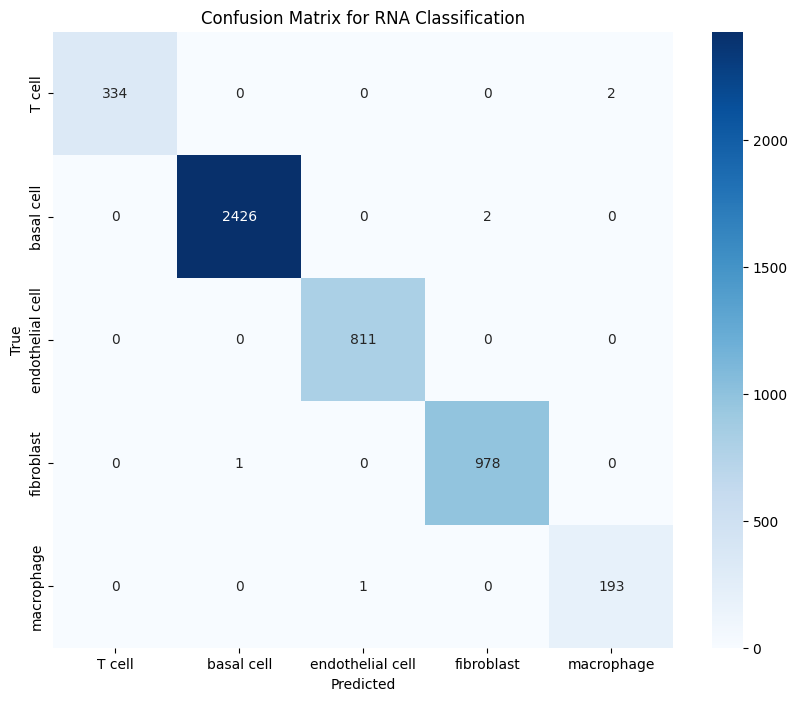

In [42]:
# Confusion matrix
cm = confusion_matrix(y_test_rna.values, y_pred_rna)

# Display confusion matrix as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for RNA Classification')
plt.show()

In [43]:
y_pred_gex = model_rna.predict(X_test_gex)

# Classification report
print("Classification Report for GEX:")
print(classification_report(y_test_gex.values, y_pred_gex, target_names=label_encoder.classes_))

Classification Report for GEX:
                  precision    recall  f1-score   support

          T cell       0.93      0.41      0.57       336
      basal cell       0.83      0.58      0.68      2428
endothelial cell       0.67      0.21      0.32       811
      fibroblast       0.97      0.31      0.47       979
      macrophage       0.07      0.87      0.13       194

        accuracy                           0.46      4748
       macro avg       0.70      0.48      0.44      4748
    weighted avg       0.81      0.46      0.55      4748



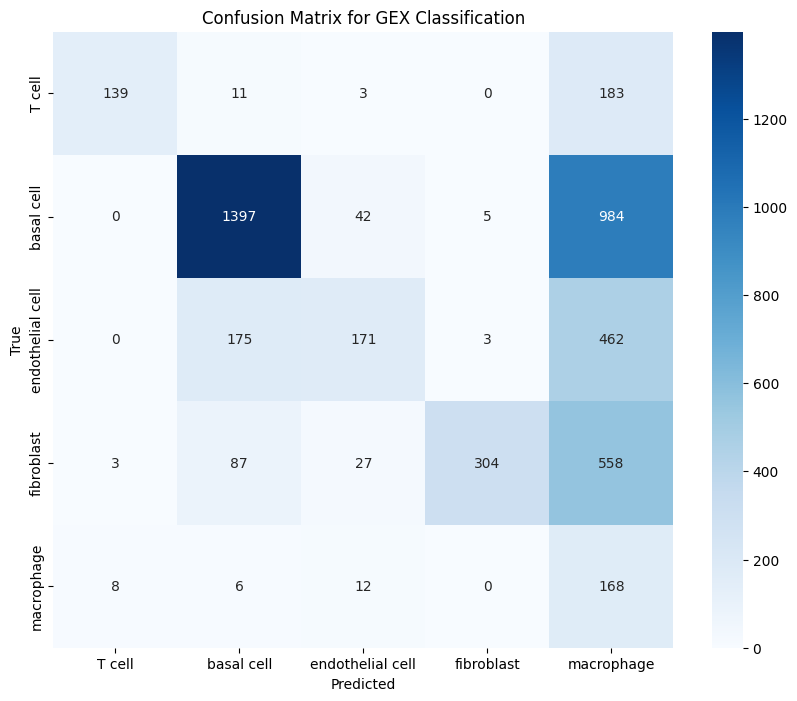

In [44]:
# Confusion matrix
cm = confusion_matrix(y_test_gex.values, y_pred_gex)
# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for GEX Classification')
plt.show()

In [45]:
y_pred_fake = model_rna.predict(X_test_fake)

# Classification report
print("Classification Report for FAKE:")
print(classification_report(y_test_fake.values, y_pred_fake, target_names=label_encoder.classes_))

Classification Report for FAKE:
                  precision    recall  f1-score   support

          T cell       1.00      0.11      0.20       336
      basal cell       0.94      1.00      0.97      2428
endothelial cell       0.97      0.94      0.95       811
      fibroblast       0.97      0.96      0.97       979
      macrophage       0.42      0.82      0.55       194

        accuracy                           0.91      4748
       macro avg       0.86      0.77      0.73      4748
    weighted avg       0.94      0.91      0.90      4748



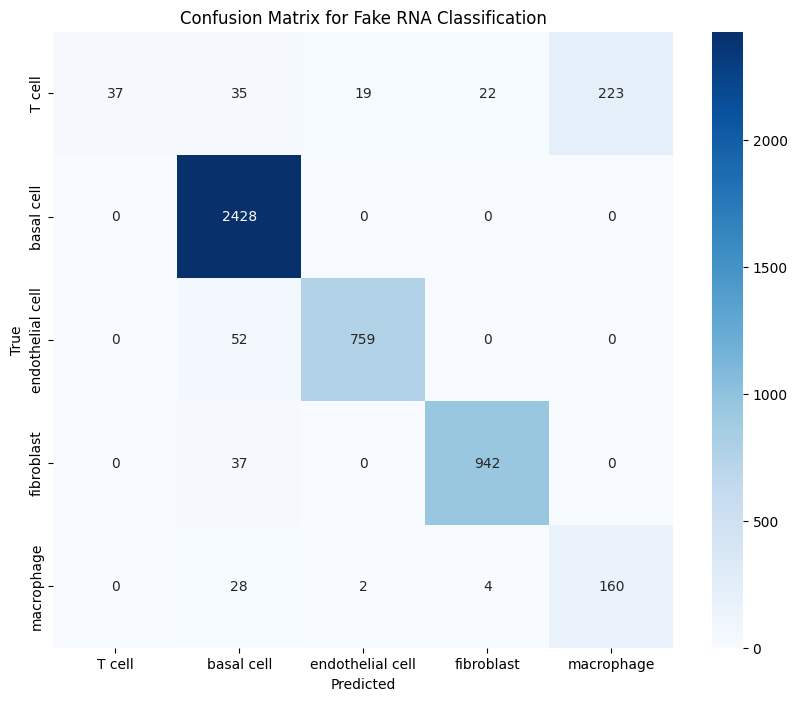

In [46]:
# Confusion matrix
cm = confusion_matrix(y_test_fake.values, y_pred_fake)

# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Fake RNA Classification')
plt.show()


In [68]:
print("true:", label_encoder.inverse_transform(y_true[:20]))
print("pred:", label_encoder.inverse_transform(y_pred[:20]))

NameError: name 'y_true' is not defined